# Bitmask as a Data Container

Beyond tile indexing, the QBTiles bitmask structure can serve as a **spatial data compression format**.

The key insight: when spatial data is distributed across an irregular grid, traditional formats store both **grid IDs** and **values**. But if the data lives on a quadtree, the bitmask already encodes *where* each value belongs. Grid IDs become zero-cost — position is implicit in the tree structure.

This example demonstrates this with South Korea's 100m population grid (931K cells):
- Read raw census data and convert grid IDs to coordinates
- Encode coordinates as quadkeys in a custom CRS (EPSG:5179)
- Store population values directly in the bitmask structure
- Compare file size against Parquet

Helper functions are in [`popu_utils.py`](https://github.com/vuski/qbtiles/blob/main/docs/examples/popu_utils.py).

Data source: [Statistics Korea (KOSTAT) 100m population grid, 2021](https://sgis.kostat.go.kr)

## 1. Load raw census data from zip

In [1]:
import os, sys, zipfile, io
import pandas as pd

sys.path.insert(0, os.path.join("..", "..", "src", "python"))
import qbtiles as qbt
import popu_utils

# Read all txt files from zip
zip_path = "pop_100m_epsg5179_2021.zip"
frames = []
with zipfile.ZipFile(zip_path) as zf:
    for name in zf.namelist():
        if name.endswith(".txt"):
            with zf.open(name) as f:
                df_part = pd.read_csv(f, sep='^', header=None,
                                      names=["year", "cell", "code", "popu"],
                                      dtype={"year": str, "cell": str, "code": str, "popu": int})
                frames.append(df_part)

df_raw = pd.concat(frames, ignore_index=True)
print(f"Raw records: {len(df_raw):,}")
df_raw.head()

Raw records: 3,146,430


,year,cell,code,popu
0,2021,가다780670,to_in_001,8
1,2021,가다781673,to_in_001,5
2,2021,가다780672,to_in_001,8
3,2021,가다806646,to_in_001,5
4,2021,가다782673,to_in_001,8


## 2. Convert grid IDs to coordinates and pivot

KOSTAT grid IDs (e.g. `가다780670`) encode position using Korean syllable prefixes for 100km blocks. We convert these to EPSG:5179 projected coordinates, then pivot the data so each grid cell has total/male/female columns.

In [2]:
# Convert grid IDs to x/y coordinates
df_xy = popu_utils.convert_grid_id_to_xy(df_raw, "cell", "100m")
df = pd.concat([df_xy, df_raw[["code", "popu"]]], axis=1)

# Map codes: to_in_001=total, to_in_007=male, to_in_008=female
code_map = {"to_in_001": "total", "to_in_007": "male", "to_in_008": "female"}
df["code"] = df["code"].map(code_map)

# Pivot: one row per grid cell
df_pivot = df.pivot_table(index=["cell_x", "cell_y"], columns="code", values="popu", fill_value=0).reset_index()
df_pivot[["total", "male", "female"]] = df_pivot[["total", "male", "female"]].astype(int)
df_pivot = df_pivot[df_pivot["total"] > 0]
print(f"Grid cells with population: {len(df_pivot):,}")
df_pivot.head()

Grid cells with population: 931,495


code,cell_x,cell_y,female,male,total
0,746950,2001050,13,18,28
1,746950,2001150,0,0,5
2,747050,2000150,0,0,5
3,747050,2001050,5,8,8
5,747150,2000650,5,0,5


## 3. Encode as quadkeys

EPSG:5179, 100m grid → `zoom=13` (because `819200 / 2^13 = 100`).

## 2.5 Visualize the grid distribution

The populated cells form an irregular pattern — dense in cities, sparse in mountains and coastlines. This is what makes bitmask encoding effective: empty regions cost zero bits.

Total possible cells (8192x8192): 67,108,864
Occupied cells: 931,495 (1.4%)
Empty cells: 66,177,369 (98.6%)


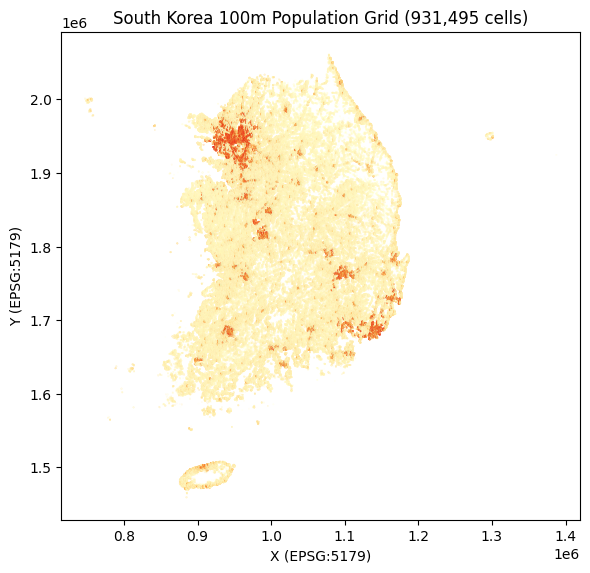

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(6, 10))

# Color by log population for visibility
pop = np.log1p(df_pivot["total"].values)

ax.scatter(df_pivot["cell_x"], df_pivot["cell_y"], s=0.01, c=pop, cmap="YlOrRd", alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"South Korea 100m Population Grid ({len(df_pivot):,} cells)")
ax.set_xlabel("X (EPSG:5179)")
ax.set_ylabel("Y (EPSG:5179)")

# Stats
total_possible = (819200 // 100) ** 2  # 8192 x 8192
occupancy = len(df_pivot) / total_possible * 100
print(f"Total possible cells (8192x8192): {total_possible:,}")
print(f"Occupied cells: {len(df_pivot):,} ({occupancy:.1f}%)")
print(f"Empty cells: {total_possible - len(df_pivot):,} ({100-occupancy:.1f}%)")

plt.tight_layout()
plt.show()

In [4]:
origin_x, origin_y = 700000, 1300000
extent = 819200  # 100m * 2^13
zoom = 13

df_pivot["quadkey"] = [
    qbt.encode_custom_quadkey(x, y, zoom, origin_x, origin_y, extent)
    for x, y in zip(df_pivot["cell_x"], df_pivot["cell_y"])
]

# Verify round-trip on first entry
qk = df_pivot["quadkey"].iloc[0]
x, y = qbt.decode_custom_quadkey(qk, zoom, origin_x, origin_y, extent)
print(f"quadkey {qk} -> ({x}, {y})")
print(f"Original: ({df_pivot['cell_x'].iloc[0]}, {df_pivot['cell_y'].iloc[0]})")
print(f"Match: {x == df_pivot['cell_x'].iloc[0] and y == df_pivot['cell_y'].iloc[0]}")

quadkey 244021529 -> (746950, 2001050)
Original: (746950, 2001050)
Match: True


The final table has no grid IDs or coordinates — just a quadkey (which the bitmask will encode implicitly) and the values. This is what gets stored:

In [5]:
# Final table: quadkey encodes position, values follow directly
df_pivot[["quadkey", "total", "male", "female"]].head(10)

code,quadkey,total,male,female
0,244021529,28,18,13
1,244021531,5,0,0
2,244020118,5,0,0
3,244021532,8,8,5
5,244020157,5,0,5
7,244020280,5,0,0
8,244020283,5,0,5
9,244020276,87,60,25
10,244020278,8,5,5
11,244020284,5,5,5


## 4. Build QBT columnar file

Population values (total, male, female) are stored as varint columns using `write_qbt_columnar()`. The bitmask encodes which cells exist; values follow in columnar order.

In [6]:
# Build quadtree from quadkeys
quadkey_info = list(zip(
    df_pivot["quadkey"], [""] * len(df_pivot),
    [0] * len(df_pivot), [0] * len(df_pivot), [1] * len(df_pivot)
))
root = qbt.build_quadtree(quadkey_info)

# Serialize bitmask
bitmask_bytes, leaf_count = qbt.serialize_bitmask(root)
print(f"Bitmask: {len(bitmask_bytes):,} bytes, {leaf_count:,} leaves")

# Sort values by quadkey (same order as bitmask BFS leaves)
df_sorted = df_pivot.sort_values("quadkey").reset_index(drop=True)
totals = df_sorted["total"].tolist()
males = df_sorted["male"].tolist()
females = df_sorted["female"].tolist()

# Write columnar QBT file
output_path = "pop_korea_100m.qbt.gz"
qbt.write_qbt_columnar(
    output_path, bitmask_bytes,
    columns=[
        (qbt.TYPE_VARINT, totals),
        (qbt.TYPE_VARINT, males),
        (qbt.TYPE_VARINT, females),
    ],
    leaf_count=leaf_count,
    zoom=zoom,
    crs=5179,
    origin_x=origin_x, origin_y=origin_y,
    extent_x=extent, extent_y=extent,
    fields=[
        {"type": qbt.TYPE_VARINT, "offset": 0, "name": "total"},
        {"type": qbt.TYPE_VARINT, "offset": 0, "name": "male"},
        {"type": qbt.TYPE_VARINT, "offset": 0, "name": "female"},
    ],
    compress=True,
)

file_size = os.path.getsize(output_path)
print(f"File: {output_path} ({file_size:,} bytes, {file_size/1024/1024:.1f} MB)")
print(f"Per cell: {file_size/leaf_count:.2f} bytes (coords + 3 values)")

## 5. Deserialize and verify

Read back the .qbt.gz file using `read_qbt_header()` and verify all values match.

In [7]:
import gzip as gz

# Read and decompress
header = qbt.read_qbt_header(output_path)
print(f"zoom={header['zoom']}, crs={header['crs']}, fields={len(header['fields'])}")
print(f"Fields: {[f['name'] for f in header['fields']]}")

# Full decompress to get values
with open(output_path, "rb") as f:
    raw = gz.decompress(f.read())

# Read bitmask section to count leaves
bm_start = header["header_size"]
bm_compressed = raw[bm_start:bm_start + header["bitmask_length"]]
bm_raw = gz.decompress(bm_compressed)

# Read varint values
from io import BytesIO
val_offset = header["values_offset"]
val_io = BytesIO(raw[val_offset:])

def read_varints(bio, count):
    return [qbt.read_varint(bio) for _ in range(count)]

totals_read = read_varints(val_io, leaf_count)
males_read = read_varints(val_io, leaf_count)
females_read = read_varints(val_io, leaf_count)

print(f"Read back {leaf_count:,} cells")

# Verify against original
mismatches = 0
for i in range(leaf_count):
    if totals_read[i] != totals[i] or males_read[i] != males[i] or females_read[i] != females[i]:
        mismatches += 1
print(f"Mismatches: {mismatches}")

## 6. Size comparison

Compare against Parquet for the same data (931K cells x 3 values).

In [8]:
qb_gz_size = os.path.getsize(output_path)

# Save as parquet for comparison
parquet_path = "pop_korea_100m.parquet"
df_pivot[["quadkey", "total", "male", "female"]].to_parquet(parquet_path, index=False)
parquet_size = os.path.getsize(parquet_path)

# Parquet + zip
parquet_zip_path = "pop_korea_100m_parquet.zip"
with zipfile.ZipFile(parquet_zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(parquet_path)
parquet_zip_size = os.path.getsize(parquet_zip_path)

print(f'{"Format":<25} {"Size":>12} {"Ratio":>12}')
print("-" * 52)
for name, size in [
    ("Parquet", parquet_size),
    ("Parquet + zip", parquet_zip_size),
    ("QBTiles columnar (gzip)", qb_gz_size),
]:
    pct = size / parquet_zip_size * 100
    print(f"{name:<25} {size/1024/1024:>9.1f} MB {pct:>10.0f}%")

# Cleanup
for f in [output_path, parquet_path, parquet_zip_path]:
    os.remove(f)

## 7. Spatial range query via quadkey

Once decoded into a sorted array, any subregion can be retrieved with a binary search — **O(log N)** instead of scanning all rows.

Because quadkeys preserve spatial hierarchy (a zoom-5 prefix shares all its zoom-13 descendants as a contiguous range), `searchsorted` on a sorted quadkey array gives the start and end indices instantly. This is something Hilbert-curve-based tile IDs (PMTiles) cannot do — Hilbert IDs don't share prefixes across zoom levels.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Re-serialize for this demo (was cleaned up above) ---
quadkey_info = list(zip(
    df_pivot["quadkey"], [""] * len(df_pivot),
    [0] * len(df_pivot), [0] * len(df_pivot), [1] * len(df_pivot)
))
root = qbt.build_quadtree(quadkey_info)
bitmask_bytes, leaf_count = qbt.serialize_bitmask(root)
df_sorted = df_pivot.sort_values("quadkey").reset_index(drop=True)

output_path = "pop_korea_100m.qbt.gz"
qbt.write_qbt_columnar(
    output_path, bitmask_bytes,
    columns=[
        (qbt.TYPE_VARINT, df_sorted["total"].tolist()),
        (qbt.TYPE_VARINT, df_sorted["male"].tolist()),
        (qbt.TYPE_VARINT, df_sorted["female"].tolist()),
    ],
    leaf_count=leaf_count, zoom=zoom, crs=5179,
    origin_x=origin_x, origin_y=origin_y,
    extent_x=extent, extent_y=extent,
    fields=[
        {"type": qbt.TYPE_VARINT, "offset": 0, "name": "total"},
        {"type": qbt.TYPE_VARINT, "offset": 0, "name": "male"},
        {"type": qbt.TYPE_VARINT, "offset": 0, "name": "female"},
    ],
    compress=True,
)

# --- Decode into sorted arrays ---
qk_arr = np.array(df_sorted["quadkey"].values, dtype=np.int64)
val_arr = np.array(df_sorted[["total", "male", "female"]].values, dtype=np.int32)


def query_subregion(qk_arr, val_arr, parent_qk_int, parent_zoom, leaf_zoom):
    """Query all leaf entries under a parent quadkey using binary search."""
    shift = 2 * (leaf_zoom - parent_zoom)
    qk_min = parent_qk_int << shift
    qk_max = qk_min | ((1 << shift) - 1)
    i_start = np.searchsorted(qk_arr, qk_min)
    i_end = np.searchsorted(qk_arr, qk_max, side="right")
    return qk_arr[i_start:i_end], val_arr[i_start:i_end]


# --- Query: Seoul area at zoom 5 ---
seoul_qk_z5 = qbt.encode_custom_quadkey(950000, 1950000, 5, origin_x, origin_y, extent)
sub_qk, sub_val = query_subregion(qk_arr, val_arr, seoul_qk_z5, 5, zoom)

print(f"Total entries: {len(qk_arr):,}")
print(f"Zoom-5 subregion: {len(sub_qk):,} entries ({len(sub_qk)/len(qk_arr)*100:.1f}%)")

# --- Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: full map with box
axes[0].scatter(df_pivot["cell_x"], df_pivot["cell_y"], s=0.01,
                c=np.log1p(df_pivot["total"].values), cmap="YlOrRd", alpha=0.3)
tile_size_z5 = extent / (2**5)
cx, cy = qbt.decode_custom_quadkey(seoul_qk_z5, 5, origin_x, origin_y, extent)
rect = plt.Rectangle((cx - tile_size_z5/2, cy - tile_size_z5/2),
                       tile_size_z5, tile_size_z5,
                       linewidth=2, edgecolor="blue", facecolor="none")
axes[0].add_patch(rect)
axes[0].set_aspect("equal")
axes[0].set_title("Full grid (blue = queried tile)")

# Right: subregion only
coords = np.array([qbt.decode_custom_quadkey(int(qk), zoom, origin_x, origin_y, extent) for qk in sub_qk])
axes[1].scatter(coords[:, 0], coords[:, 1], s=0.5,
                c=np.log1p(sub_val[:, 0]), cmap="YlOrRd", alpha=0.7)
axes[1].set_aspect("equal")
axes[1].set_title(f"Subregion ({len(sub_qk):,} cells)")

plt.tight_layout()
plt.show()

os.remove(output_path)